# Оптимизация размещения сети ПВЗ Ozon (Красноярск)
**Команда №3** | Мидтерм

## Команда
- Васильев Дмитрий Сергеевич
- Буков Семен Алексеевич
- Моисеев Богдан Константинович

**Цель:** Применить геоаналитические методы для анализа существующей сети ПВЗ Ozon и определения оптимальных мест для новых точек.

В данном ноутбуке представлены:
1. Развернутый EDA по ПВЗ и населению.
2. Бейзлайн гексагональной карты (H3).
3. Анализ текущего покрытия.
    - Сколько гексагонов полностью не охвачены сетью Ozon
    - Какие районы имеют наименьшее количество ПВЗ на человека?
4. Оценка индекса конкуренции и потенциала.
    - В каких гексагонах индекс "ПВЗ на человека" превышает средний по городу
в 2+ раза?
    - В каких гексагонах индекс минимален при высокой плотности населения?
5. Интерактивная визуализация результатов.

### Источники данных
Для обеспечения точности анализа были использованы следующие наборы данных:

| Данные | Источник | Описание |
| :--- | :--- | :--- |
| **Население** | Росстат (Перепись 2020) | Официальные данные по 7 административным районам г. Красноярска. |
| **Геоданные** | OpenStreetMap (OSM) | Границы города, районов и жилые здания (выкачано через OSMnx). |
| **Пункты Ozon** | Внутренний датасет | Актуальный список из 420 ПВЗ с координатами. |
| **Сетка** | Uber H3 | Гексагональная сетка с разрешением 8 (Neighborhood level). |

In [2]:
import os
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import folium
from shapely.geometry import shape, Point

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path.cwd().parent
processed_dir = BASE_DIR / "data" / "processed"
HEX_PATH = processed_dir / "hexagons_final.geojson"
PVZ_PATH = processed_dir / "pvz_krasnoyarsk.csv"

## 1. Развернутый EDA по собранным данным

### Методология анализа
#### Выбор гексагональной сетки (Resolution 8)
Мы используем стандарт **Uber H3** с разрешением **8**, так как он оптимально подходит для городского планирования:
* **Средняя площадь:** ~0.737 км².
* **Радиус (центр-вершина):** ~537 метров.
* **Обоснование:** Данный масштаб соответствует зоне 5-10 минутной пешей доступности, что критически важно для выбора локации ПВЗ "у дома".

#### Оценка населения (Dasymetric Mapping)
Распределение населения из административных районов в гексагоны производилось пропорционально **суммарной этажности жилых зданий**. Мы предполагаем, что плотность населения выше там, где выше плотность и этажность застройки.

**Формула расчета:**
$$Pop_{hex} = Pop_{district} \times \frac{\sum Levels_{hex}}{\sum Levels_{district}}$$

In [3]:
pvz_df = pd.read_csv(PVZ_PATH)
pvz_gdf = gpd.GeoDataFrame(
    pvz_df, 
    geometry=[Point(xy) for xy in zip(pvz_df.longitude, pvz_df.latitude)], 
    crs="EPSG:4326"
)

def load_geojson(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    features = data['features']
    geoms = [shape(f['geometry']) for f in features]
    props = [f['properties'] for f in features]
    return gpd.GeoDataFrame(props, geometry=geoms, crs="EPSG:4326")


hexagons = load_geojson(HEX_PATH)

print(f"Всего пунктов выдачи (ПВЗ): {len(pvz_gdf)}")
print(f"Всего гексагонов в сетке (res 8): {len(hexagons)}")

Всего пунктов выдачи (ПВЗ): 420
Всего гексагонов в сетке (res 8): 483


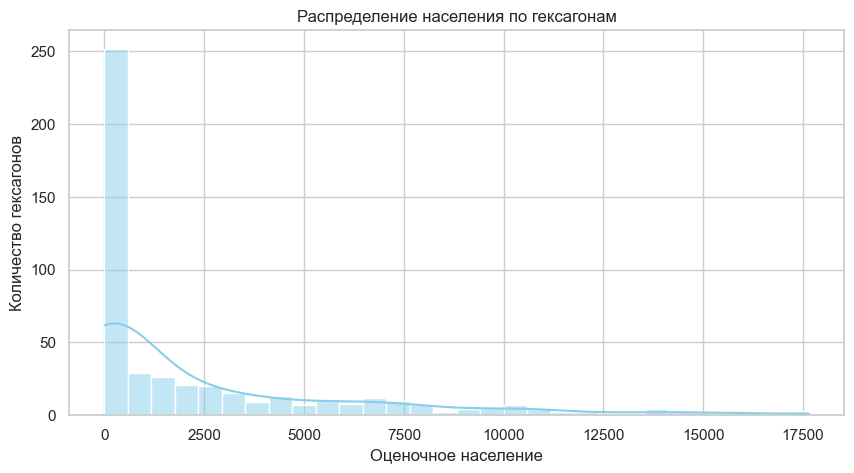


Описательная статистика по населению:


count      483.0
mean      2459.0
std       3760.0
min          0.0
25%          0.0
50%        377.0
75%       3424.0
max      17652.0
Name: population_estimated, dtype: float64

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(hexagons['population_estimated'], bins=30, kde=True, color='skyblue')
plt.title('Распределение населения по гексагонам')
plt.xlabel('Оценочное население')
plt.ylabel('Количество гексагонов')
plt.show()

print("\nОписательная статистика по населению:")
display(hexagons['population_estimated'].describe().round(0))

In [5]:
total_pop = hexagons['population_estimated'].sum()
official_pop = 1187771

print(f"Официальные данные переписи по Красноярску: {official_pop:,.0f} чел.")
print(f"Итоговое население в модели: {total_pop:,.0f} чел.")
print(f"Отклонение от официальных данных: {(abs(total_pop - official_pop) / official_pop):.2%}")

Официальные данные переписи по Красноярску: 1,187,771 чел.
Итоговое население в модели: 1,187,765 чел.
Отклонение от официальных данных: 0.00%


## 2. Анализ текущего покрытия (Ответы на Вопрос 1)
- Сколько гексагонов полностью не охвачены сетью Ozon?
- Какие районы имеют наименьшее количество ПВЗ на человека?

Гексагонов без ПВЗ Ozon: 338 из 483 (70.0%)


C:\Users\user\AppData\Local\Temp\ipykernel_21156\2537096695.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_stats, x='pvz_per_10k_district', y='district_name', palette='viridis')


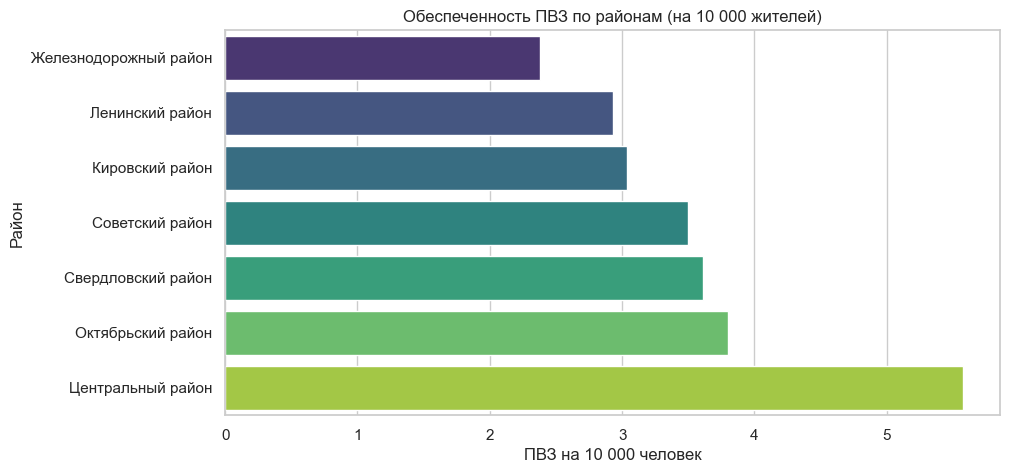

In [6]:
pvz_in_hex = gpd.sjoin(pvz_gdf, hexagons, how="inner", predicate="intersects")
pvz_counts = pvz_in_hex.groupby('h3_id').size().reset_index(name='pvz_count')
hex_results = hexagons.merge(pvz_counts, on='h3_id', how='left').fillna({'pvz_count': 0})

def calc_index(row):
    pop = row.get('population_estimated', 0)
    return (row['pvz_count'] / pop * 10000) if pop > 0 else 0

hex_results['pvz_per_10k'] = hex_results.apply(calc_index, axis=1)

uncovered_hex = len(hex_results[hex_results['pvz_count'] == 0])
total_hex = len(hex_results)
print(f"Гексагонов без ПВЗ Ozon: {uncovered_hex} из {total_hex} ({uncovered_hex/total_hex:.1%})")

district_stats = hex_results.groupby('district_name').agg({
    'population_estimated': 'sum',
    'pvz_count': 'sum'
}).reset_index()

district_stats['pvz_per_10k_district'] = (district_stats['pvz_count'] / district_stats['population_estimated']) * 10000
district_stats = district_stats.sort_values('pvz_per_10k_district')

plt.figure(figsize=(10, 5))
sns.barplot(data=district_stats, x='pvz_per_10k_district', y='district_name', palette='viridis')
plt.title('Обеспеченность ПВЗ по районам (на 10 000 жителей)')
plt.xlabel('ПВЗ на 10 000 человек')
plt.ylabel('Район')
plt.show()

## 3. Индекс конкуренции и потенциал (Ответы на Вопрос 2)
- В каких гексагонах индекс "ПВЗ на человека" превышает средний по городу
в 2+ раза?
- В каких гексагонах индекс минимален при высокой плотности населения?

In [7]:
mean_city_index = hex_results[hex_results['population_estimated'] > 0]['pvz_per_10k'].mean()
print(f"Средний индекс обеспеченности по городу: {mean_city_index:.2f} ПВЗ на 10к чел.")

over_saturated = hex_results[hex_results['pvz_per_10k'] > (mean_city_index * 2)]
print(f"\nКоличество перенасыщенных гексагонов (индекс > {mean_city_index*2:.2f}): {len(over_saturated)}")
display(over_saturated[['h3_id', 'district_name', 'population_estimated', 'pvz_count', 'pvz_per_10k']].head(3))

blind_spots = hex_results[(hex_results['pvz_count'] == 0) & (hex_results['population_estimated'] > 0)]
blind_spots = blind_spots.sort_values('population_estimated', ascending=False)

print("\nТоп-5 приоритетных гексагонов (Слепые зоны с максимальным населением):")
display(blind_spots[['h3_id', 'district_name', 'population_estimated', 'pvz_count']].head(5))

Средний индекс обеспеченности по городу: 2.94 ПВЗ на 10к чел.

Количество перенасыщенных гексагонов (индекс > 5.87): 53


,h3_id,district_name,population_estimated,pvz_count,pvz_per_10k
3,880b9a74cbfffff,Центральный район,2684.0,2.0,7.451565
10,880b9a7619fffff,Октябрьский район,6648.0,4.0,6.016847
11,880b9a741bfffff,Центральный район,4545.0,3.0,6.600660



Топ-5 приоритетных гексагонов (Слепые зоны с максимальным населением):


,h3_id,district_name,population_estimated,pvz_count
482,880b9a296bfffff,Советский район,17086.0,0.0
32,880b9a7657fffff,Октябрьский район,10554.0,0.0
73,880b9a7583fffff,Кировский район,9553.0,0.0
131,880b9a74c1fffff,Советский район,7937.0,0.0
31,880b9a7459fffff,Железнодорожный район,7659.0,0.0


## 4. Визуализация: Интерактивная гексагональная карта покрытия
На карте отображены:
1. Индекс доступности
2. Текущие ПВЗ (синие маркеры)
3. Приоритетные гексагоны-кандидаты для открытия новых точек (красный слой "Слепые зоны")

In [8]:
hex_results['blind_spot_pop'] = hex_results.apply(
    lambda r: r['population_estimated'] if r['pvz_count'] == 0 else 0, axis=1)

m = folium.Map(location=[56.01, 92.85], zoom_start=11, tiles='cartodbpositron')

folium.Choropleth(
    geo_data=hex_results,
    name='Индекс доступности ПВЗ',
    data=hex_results,
    columns=['h3_id', 'pvz_per_10k'],
    key_on='feature.properties.h3_id',
    fill_color='YlGnBu', fill_opacity=0.6, line_opacity=0.2,
    legend_name='ПВЗ на 10 000 человек'
).add_to(m)

folium.Choropleth(
    geo_data=hex_results[hex_results['blind_spot_pop'] > 0],
    name='Приоритетные гексагоны (Потенциал)',
    data=hex_results,
    columns=['h3_id', 'blind_spot_pop'],
    key_on='feature.properties.h3_id',
    fill_color='Reds', fill_opacity=0.7, line_opacity=0.2,
    legend_name='Население в зонах без ПВЗ',
    show=False
).add_to(m)

pvz_layer = folium.FeatureGroup(name="Существующие ПВЗ")
for _, row in pvz_df.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=2, color='blue', fill=True,
        popup=f"ПВЗ: {row.address_clean}",
    ).add_to(pvz_layer)
pvz_layer.add_to(m)

folium.LayerControl().add_to(m)
m

### Ограничения и допущения модели
При интерпретации результатов необходимо учитывать следующие факторы:
1. **Данные OSM:** В некоторых новых микрорайонах информация об этажности зданий может отсутствовать или быть неактуальной (по умолчанию принято значение 1 этаж)
2. **Тип застройки:** Модель фокусируется на постоянном населении и не учитывает суточную миграцию (бизнес-центры, рынки), которая также генерирует трафик для ПВЗ
3. **Перепись 2020:** Данные отражают ситуацию на момент переписи и могут не учитывать жильцов домов, сданных в 2022-2024 годах

## 3.1 Сравнительные диаграммы
Распределение гексагонов по индексу доступности (ПВЗ на человека).

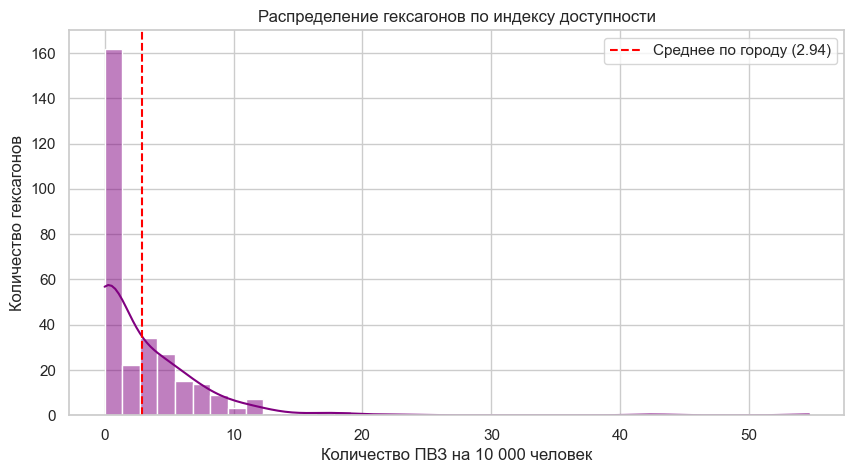

In [9]:

plt.figure(figsize=(10, 5))
sns.histplot(hex_results[hex_results['population_estimated'] > 0]['pvz_per_10k'], bins=40, kde=True, color='purple')
plt.title('Распределение гексагонов по индексу доступности')
plt.xlabel('Количество ПВЗ на 10 000 человек')
plt.ylabel('Количество гексагонов')
plt.axvline(mean_city_index, color='red', linestyle='--', label=f'Среднее по городу ({mean_city_index:.2f})')
plt.legend()
plt.show()

## 6. Прогноз увеличения покрытия населения
[cite_start]Оценка чистого прироста уникальной аудитории в 5-минутной пешей доступности после открытия новых точек[cite: 72].